In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense,SimpleRNN,Dropout
from sklearn.model_selection import train_test_split

In [12]:
data = pd.read_csv('/content/optimized_waste_management_data.csv')#/content/optimized_waste_management_data.csv

In [13]:
data.head(3)#,data.shape

,date,waste_volume,organic_waste,recyclable_waste,hazardous_waste,collection_frequency,landfill_capacity_used,recycling_rate
0,01-01-2020,48.85,31.49,12.55,4.81,Weekly,55.87,47.37
1,02-01-2020,49.45,29.76,14.76,4.94,Weekly,51.91,41.70
2,03-01-2020,51.03,32.29,13.65,5.09,Bi-weekly,53.08,58.73


In [15]:
waste_volume = data['waste_volume'].values
sclar = MinMaxScaler(feature_range=(0,1))
waste_volume = sclar.fit_transform(waste_volume.reshape(-1,1))

In [16]:
def create_sequence(data,sequence_length):
  sequence = []
  labels = []
  for i in range(len(data)-sequence_length):
    sequence.append(data[i:i+sequence_length])
    labels.append(data[i+sequence_length])
  return np.array(sequence),np.array(labels)

In [20]:
sequence_length = 10
X,y = create_sequence(waste_volume,sequence_length)

In [21]:
X

array([[[0.47691575],
        [0.49119467],
        [0.52879581],
        ...,
        [0.58305569],
        [0.57805807],
        [0.66254165]],

       [[0.49119467],
        [0.52879581],
        [0.61613517],
        ...,
        [0.57805807],
        [0.66254165],
        [0.50237982]],

       [[0.52879581],
        [0.61613517],
        [0.54569253],
        ...,
        [0.66254165],
        [0.50237982],
        [0.57686816]],

       ...,

       [[0.59495478],
        [0.45930509],
        [0.51737268],
        ...,
        [0.4578772 ],
        [0.64350309],
        [0.57187054]],

       [[0.45930509],
        [0.51737268],
        [0.60209424],
        ...,
        [0.64350309],
        [0.57187054],
        [0.72346502]],

       [[0.51737268],
        [0.60209424],
        [0.59685864],
        ...,
        [0.57187054],
        [0.72346502],
        [0.59138505]]])

In [40]:
X_test,X_train,y_test,y_train = train_test_split(X,y,test_size=0.2,random_state=42)
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape: {X_test.shape}")

Train Shape: (291, 10, 1)
Test Shape: (1160, 10, 1)


In [41]:
model = Sequential([
    SimpleRNN(units=50,activation='tanh',return_sequences=False,input_shape=(sequence_length,1)),
    Dropout(0.2),#prevent Overfitting
    Dense(units=1)#Output layer for regression
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
model.compile(optimizer='adam',loss='mean_squared_error',metrics = ["mae"])

In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_data=(X_train,y_train),verbose=1)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0624 - mae: 0.2039 - val_loss: 0.0225 - val_mae: 0.1207
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0326 - mae: 0.1424 - val_loss: 0.0133 - val_mae: 0.0931
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0209 - mae: 0.1157 - val_loss: 0.0124 - val_mae: 0.0888
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0180 - mae: 0.1098 - val_loss: 0.0103 - val_mae: 0.0818
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0171 - mae: 0.1051 - val_loss: 0.0097 - val_mae: 0.0794
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0152 - mae: 0.0984 - val_loss: 0.0094 - val_mae: 0.0784
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0137 - mae: 0.0957 - val_loss: 0.0094 - val_mae: 0.0789
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0146 - mae: 0.0971 - val_loss: 0.0096 - val_mae: 0.0796
Epoch 9/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.014

In [45]:
loss,mae = model.evaluate(X_train,y_train,verbose=0)
print(f"Test Loss: {loss:.2f}")
print(f"Test MAE: {mae:.2f}")

Test Loss: 0.01
Test MAE: 0.08


In [46]:
prediction = model.predict(X_test)
prediction = sclar.inverse_transform(prediction)
y_test_original = sclar.inverse_transform(y_test.reshape(-1,1))

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


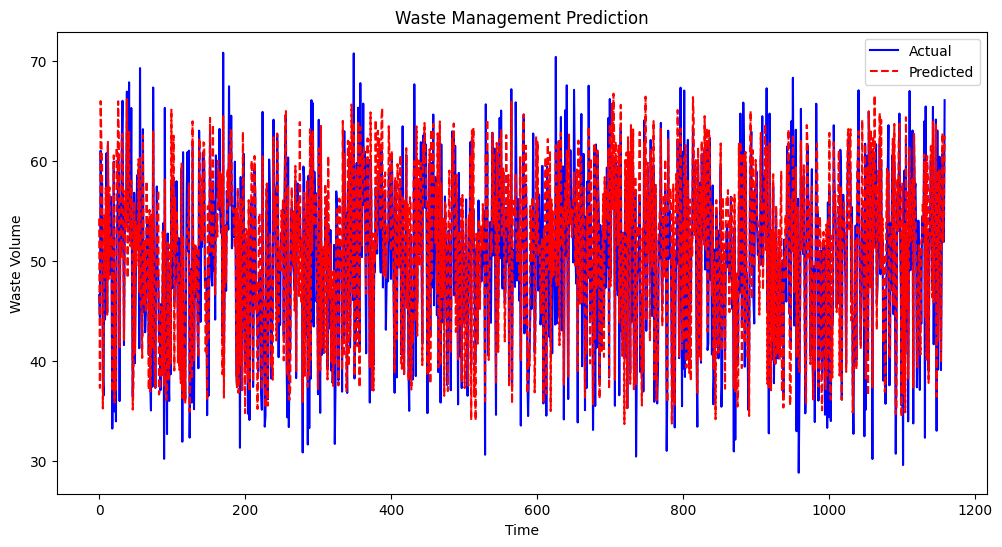

In [47]:
plt.figure(figsize=(12,6))
plt.plot(y_test_original,label='Actual',color='blue')
plt.plot(prediction,label='Predicted',color='red',linestyle='--')
plt.xlabel('Time')
plt.ylabel('Waste Volume')
plt.title('Waste Management Prediction')
plt.legend()
plt.show()